In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Data Science/Data Understanding/Heart_Disease/heart disease.csv")

In [ ]:
df.shape

(303, 14)

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# **Exploratory Data Analysis**

In [ ]:
cont_var = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_var = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

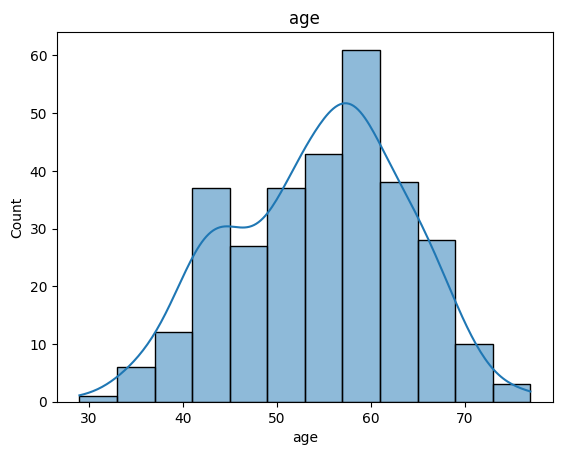

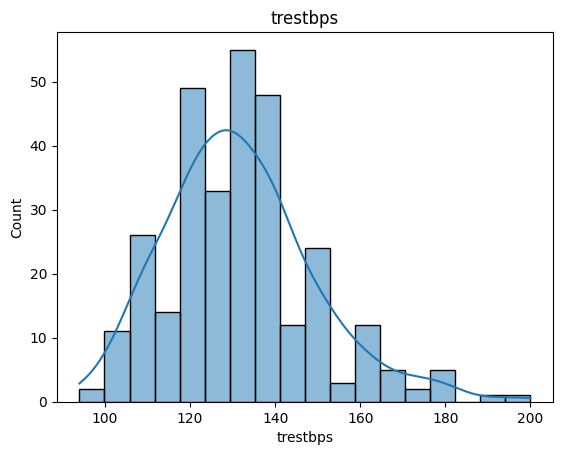

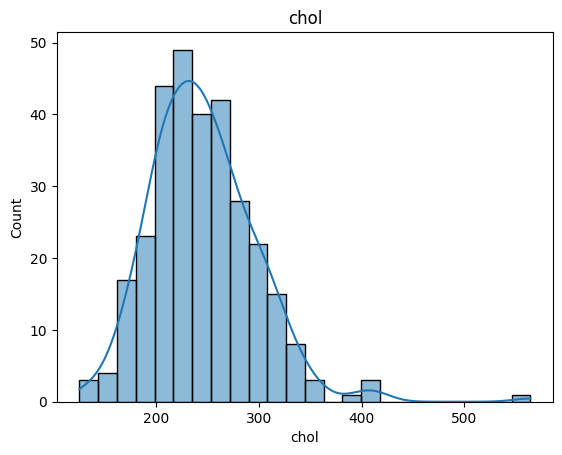

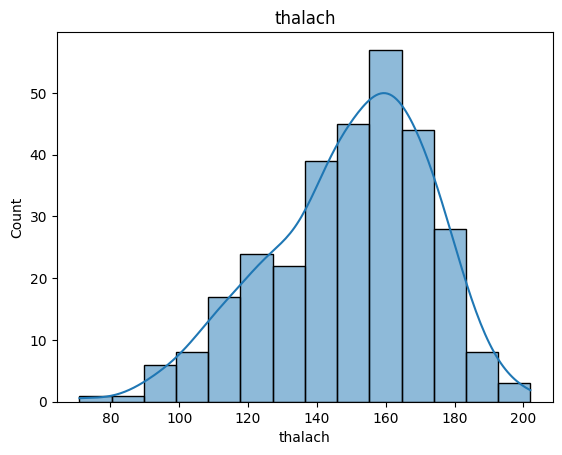

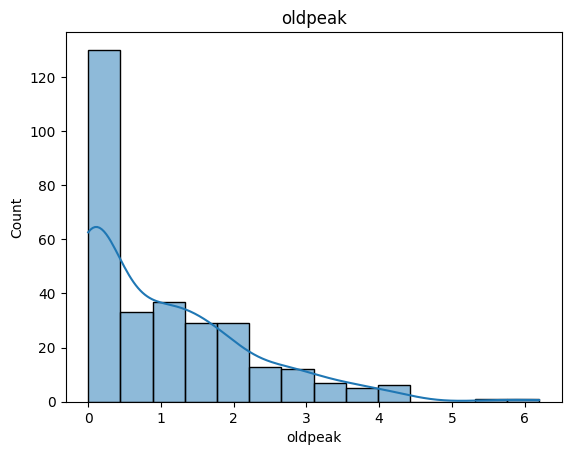

In [ ]:
# Histogram for contineous values variable
for col in cont_var:
    sns.histplot(df[col], kde = True)
    plt.title(col)
    plt.show()
"""
1. age -> Slightly Left skewed data
2. trestbps -> Right skewed data
3. chol -> Right skewed data
4. oldpeak -> Highly right skewed daata
5. thalach -> Right skewed data
"""

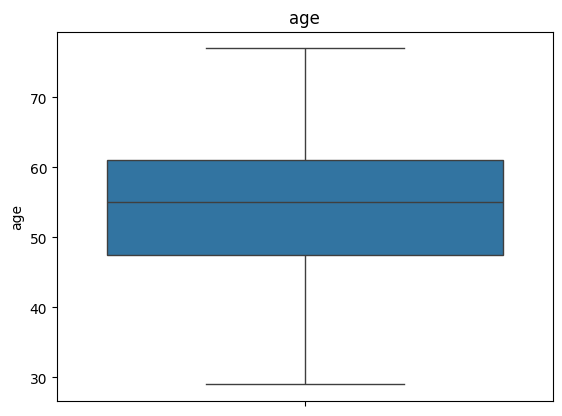

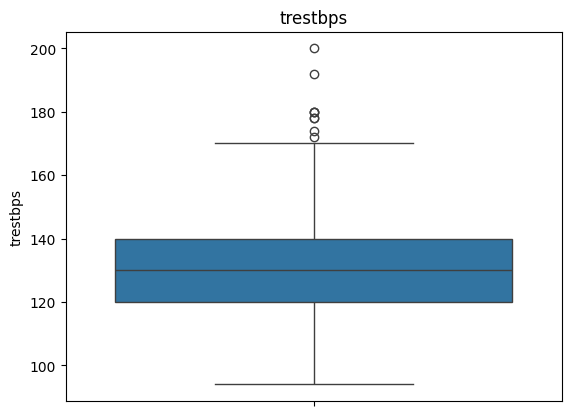

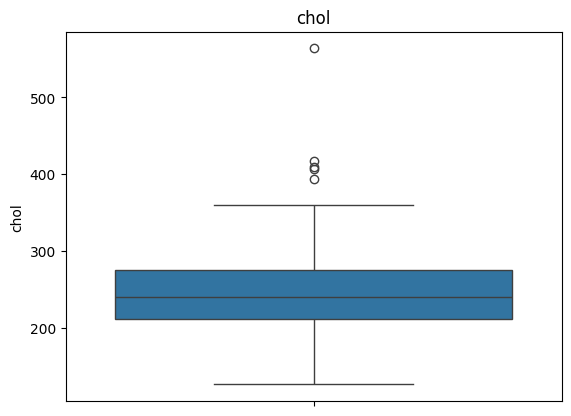

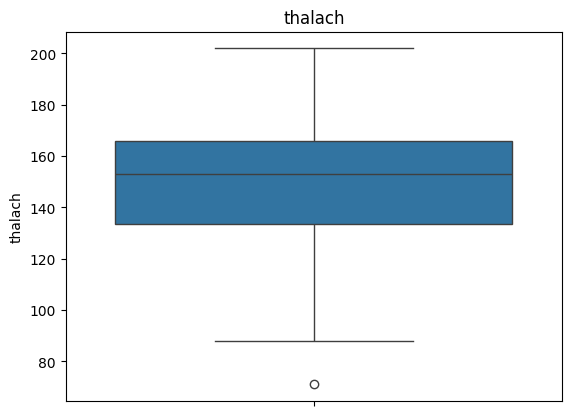

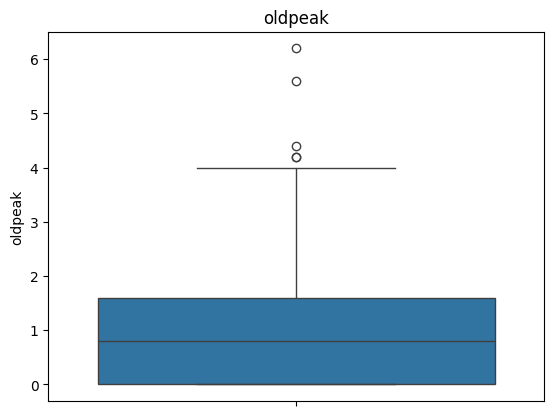

In [ ]:
for col in cont_var:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

"""
1. age -> No Outliers
2. trestbps -> Outliers are present
3. chol -> Outliers are present
4. oldpeak -> Some outliers are present
5. thalach -> Outliers are present
"""

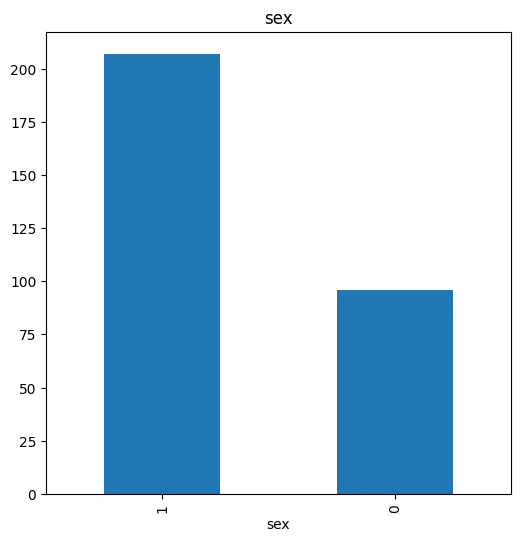

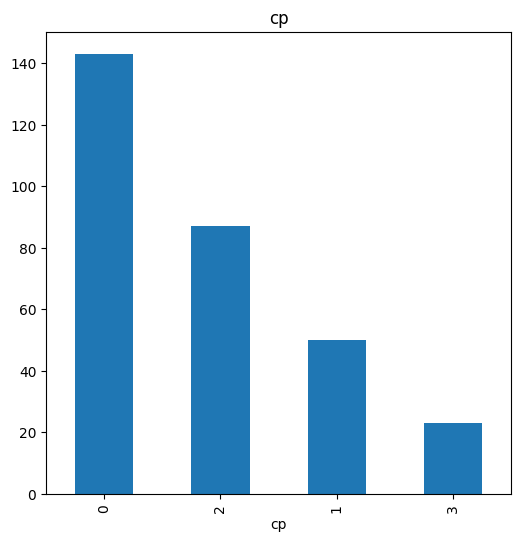

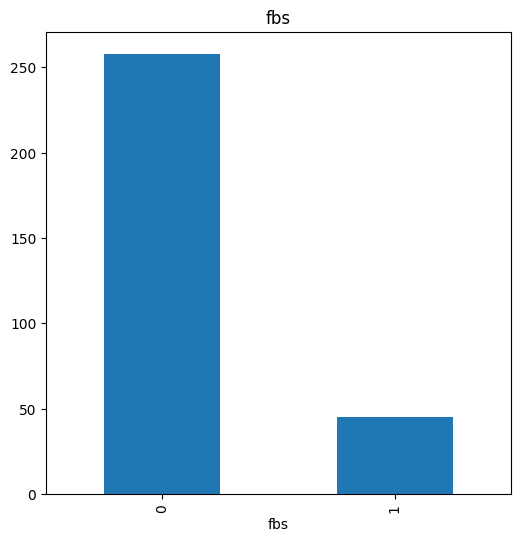

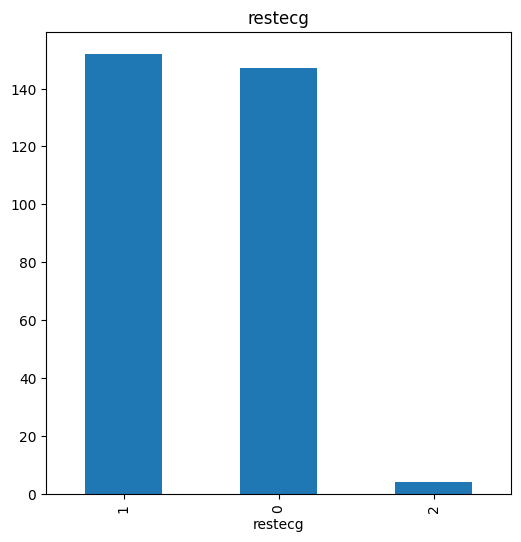

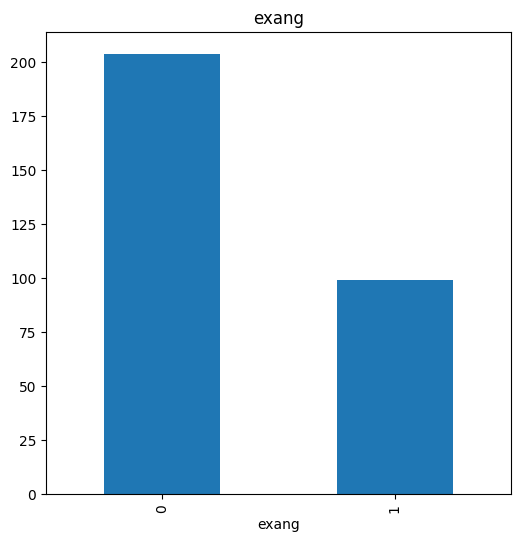

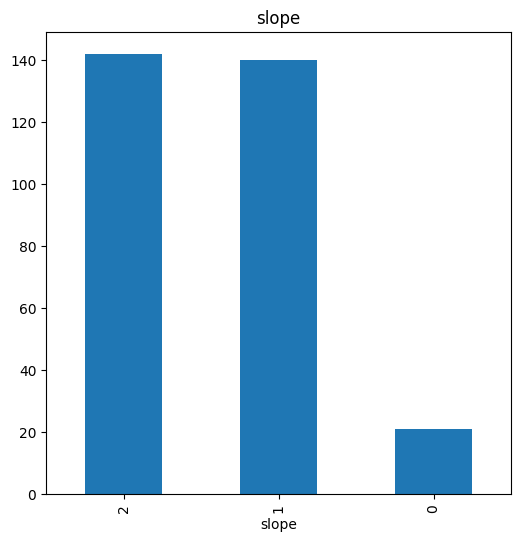

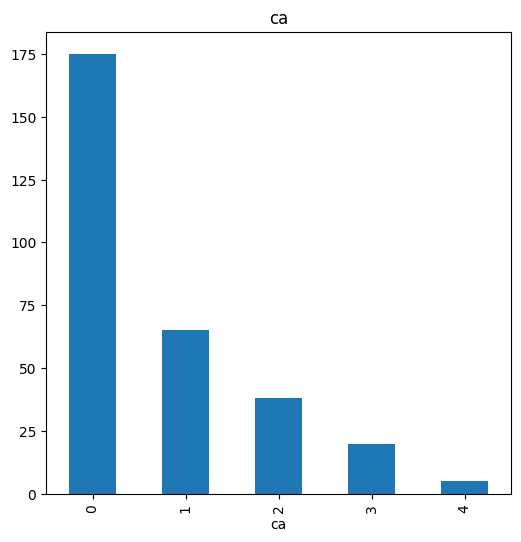

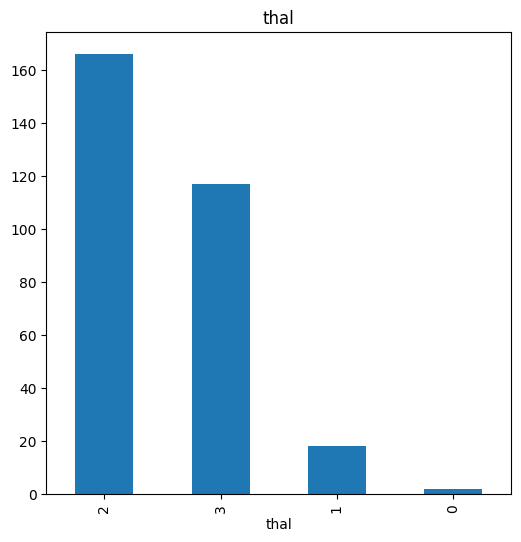

In [ ]:

for col in cat_var:
    plt.figure(figsize = (6, 6))
    df[col].value_counts().plot(kind = 'bar')
    plt.title(col)
    plt.show()
"""
1. sex -> Males are more
2. cp -> Chest pain type 0 is more i.e. Typical Angina is more
3. fbs -> Fasting blood sugar having more count who had below 120 mg/dl
4. restecg ->Resting Electrocardiographic results having more count of 0 and 1 it means Normal and ST-T wave abnormality(indicaate ischemia or heart muscle problem) respectively.
5. exang -> Exercise-inducec angina had more values of No
6. slope -> Slope of peak exercise ST segment having more count of 1 and 2 means (Flat, Downsloping). Upsloping (1) is very less
7. ca -> Number of Major Vessels colored by fluoroscopy having more count of 0 it means (no major vessels visible)
8. thal ->  Thalassemia test result has more 2 means fixed defect(permanent reduced blood flow, often from previous damage)
"""

# **Feature Transformation**

**1. Log Transfrom**

Compresses large values and spreads small ones. Highly effective for right-skewed data. +1 offset handles zero values.

Use when

-> The data is right-skewed.

-> There are large outliers.

-> Values are positive.

-> The histogram has a long right tail.

-> Income / salary features

-> House prices

-> Population data

-> Count data (views, purchases)

-> Any right-skewed continuous feature

Avoid when

Cannot apply to zero or negative values without offset.

In [ ]:
df['trestbps'].head()

,trestbps
0,145
1,130
2,130
3,120
4,120


In [ ]:
df['trestbps'] = np.log1p(df['trestbps'])

In [ ]:
df['trestbps'].head()

,trestbps
0,4.983607
1,4.875197
2,4.875197
3,4.795791
4,4.795791


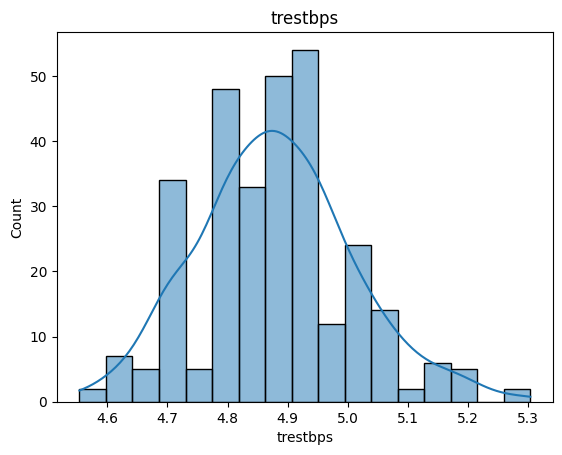

In [ ]:
sns.histplot(df['trestbps'], kde = True)
plt.title('trestbps')
plt.show()

**2. Square Root Transform**

Milder than log. Good for moderately right-skewed data. Also useful for count data with Poisson distribution.

Use when

-> Count data (events per day)

-> Poisson-distributed features

-> Moderate right skew

-> Area or rate features

Avoid when

Less effective than log for heavily skewed data

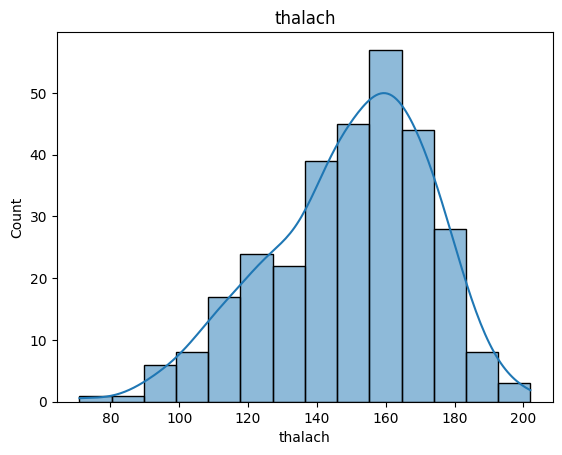

In [ ]:
sns.histplot(df['thalach'], kde = True)
plt.title('thalach')
plt.show()

In [ ]:
df['thalach'].head()

,thalach
0,150
1,187
2,172
3,178
4,163


In [ ]:
df['thalach'] = np.sqrt(df['thalach'])

In [ ]:
df['thalach'].head()

,thalach
0,12.247449
1,13.674794
2,13.114877
3,13.341664
4,12.767145


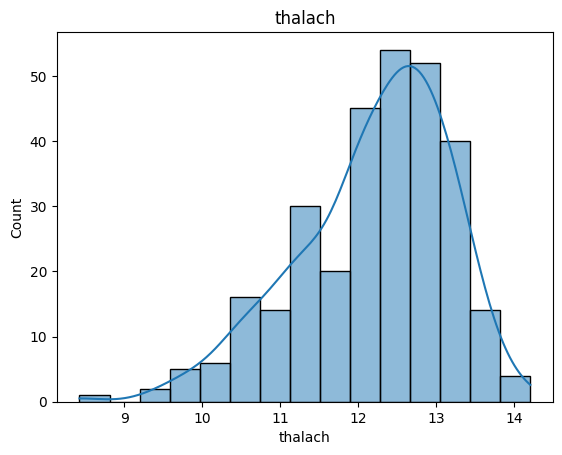

In [ ]:
sns.histplot(df['thalach'], kde = True)
plt.title('thalach')
plt.show()

**3. Box-Cox Transform**

Parametric family of transforms. Automatically finds the best λ to make data normal. Only works for positive values.

Use when

-> When optimal transform is unknown

-> Linear regression assumptions

-> ANOVA assumptions

-> Actuarial / insurance data

Avoid when

Requires strictly positive data (x > 0).

In [ ]:
df['chol'].head()

,thalach
0,150
1,187
2,172
3,178
4,163


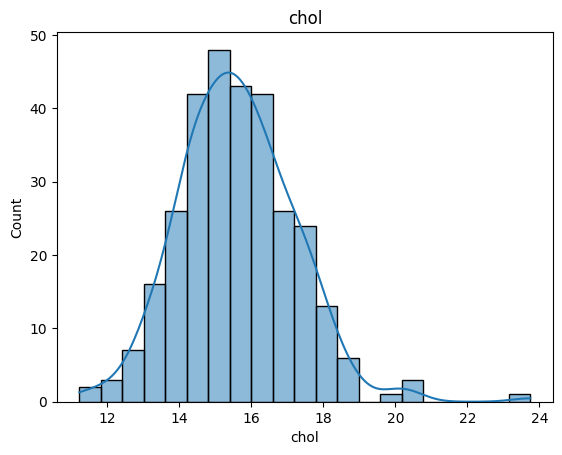

In [ ]:
sns.histplot(df['chol'], kde = True)
plt.title('chol')
plt.show()

In [ ]:
from scipy.stats import boxcox

In [ ]:
df['chol'], lam = boxcox(df['chol'])

print("Lambda:", lam)

Lambda: -0.21185127397372874


In [ ]:
df['chol'].head()

,chol
0,2.070541
1,2.090233
2,2.032970
3,2.074129
4,2.185373


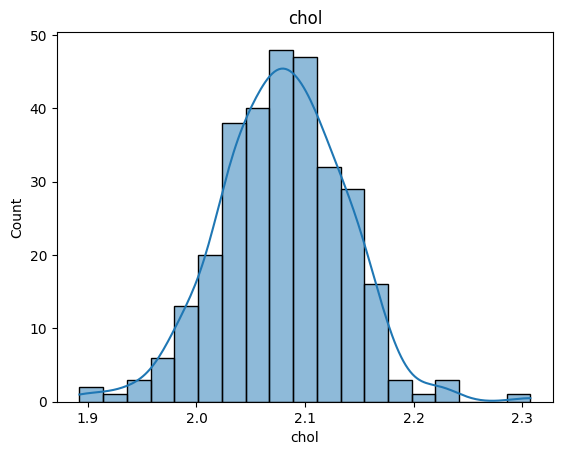

In [ ]:
sns.histplot(df['chol'], kde = True)
plt.title('chol')
plt.show()

**4. Yeo-Johnson Transform**

Like Box-Cox but works on zero and negative values too. More flexible and generally preferred over Box-Cox.

Use when

-> General-purpose normalization

-> When Box-Cox fails (zeros/negatives)

-> Temperature, returns, profit/loss

-> Any real-valued feature

Avoid when

Slightly more complex — if data is positive, Box-Cox is simpler.

In [ ]:
data = pd.DataFrame({
    'Salary': [-50, -20, 0, 10, 50, 100, 500]
})

In [ ]:
data.head()

,Salary
0,-50
1,-20
2,0
3,10
4,50


In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

data['Salary'] = pt.fit_transform(data[['Salary']])

In [ ]:
data.head()

,Salary
0,-1.697836
1,-0.642205
2,-0.135351
3,-0.039166
4,0.208965


**5. Quantile Transform**

Ranks data and maps it to a target distribution (uniform or Gaussian). Very powerful — removes all distributional assumptions.

Use when

-> Any skewed distribution

-> When distribution shape is unknown

-> Before tree-based models (less critical)

-> Linear models needing normality

Avoid when

Distorts distances between values — use carefully with distance-based algorithms.

In [ ]:
df['oldpeak'].head()

,oldpeak
0,2.3
1,3.5
2,1.4
3,0.8
4,0.6


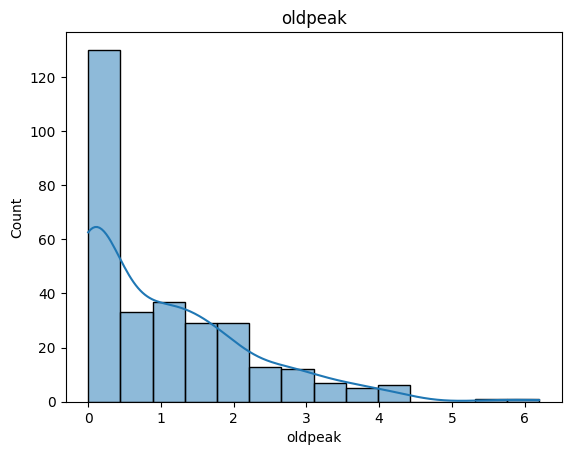

In [ ]:
sns.histplot(df['oldpeak'], kde = True)
plt.title('oldpeak')
plt.show()

In [ ]:
from sklearn.preprocessing import QuantileTransformer

# for Uniform distribution
qt = QuantileTransformer(
    output_distribution='uniform',
    random_state=42
)

In [ ]:
df['oldpeak'] = qt.fit_transform(df[['oldpeak']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (303). n_quantiles is set to n_samples.
  warnings.warn(


In [ ]:
df['oldpeak'].head()

,oldpeak
0,0.855960
1,0.956954
2,0.682119
3,0.518212
4,0.468543


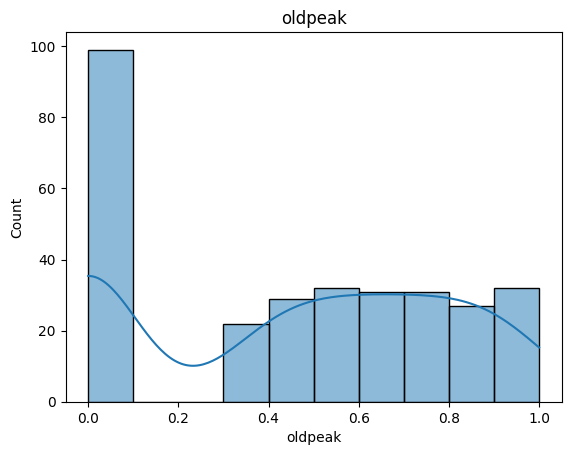

In [ ]:
sns.histplot(df['oldpeak'], kde = True)
plt.title('oldpeak')
plt.show()

In [ ]:
# for Normal distribution
qt = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)

In [ ]:
df['oldpeak'] = qt.fit_transform(df[['oldpeak']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (303). n_quantiles is set to n_samples.
  warnings.warn(


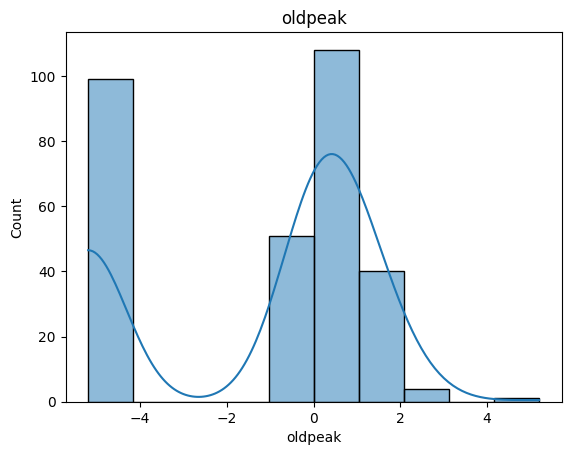

In [ ]:
sns.histplot(df['oldpeak'], kde = True)
plt.title('oldpeak')
plt.show()

**6. Reciprocal(1/x) Transform**

Flips the scale — large values become small and vice versa. Very aggressive compression of the right tail.

Use when

-> Reaction times

-> Speed vs. time relationships

-> Very heavy right skew

Avoid when

Reverses the order of values. Cannot use when x = 0.

In [ ]:
data = pd.DataFrame({
    'Salary': [10, 20, 30, 40, 50, 500]
})

In [ ]:
data.head()

,Salary
0,10
1,20
2,30
3,40
4,50


In [ ]:
data['Salary'] = 1 / data['Salary']

In [ ]:
data.head()

,Salary
0,0.100000
1,0.050000
2,0.033333
3,0.025000
4,0.020000
